# HI de Transformador y Fecha de Mantenimiento (v3.5.1)

Incluye captura explícita de **última fecha de mantenimiento** (variable y UI), curvas, tabla y exportación HTML.

In [1]:

# %% Imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, Optional, Tuple
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize'] = (10,5)


In [2]:

# %% Configuración
WEIGHTS_FUNC = {'ratio':8,'Rdev':6,'Iexc':5,'DGA':10}
WEIGHTS_DIEL = {'PF20':10,'BDV':3,'Acidez':2,'IFT':2,'H2O':6,'inhibidor':3,'furanos':8}
THRESHOLDS = {
  'ratio_error_pct':{'green_max':0.5,'amber_max':1.0},
  'PF20_pct':{'green_max':0.5,'amber_max':1.0},
  'BDV_kV':{'green_min':60,'amber_min':50},
  'H2O_mgkg':{'green_max':15,'amber_max':20},
  'Acidez_mgKOHg':{'green_max':0.03,'amber_max':0.1},
  'IFT_mNm':{'green_min':40,'amber_min':28},
  'Inhibidor_pct':{'green_min':0.3,'amber_min':0.15},
  'FAL_mgkg':{'green_max':0.1,'amber_max':0.5}
}
THERMAL = {'use_hotspot':True,'hotspot_offset_C':10.0,'FAA_norm_lo':1.0,'FAA_norm_hi':4.0}
RISK = {'alpha':0.50,'beta':0.35,'gamma':0.15,'umbral_RM':0.70}
COLS = {'fecha':'fecha','ratio_error_pct':'error_relacion_%','Rdev_metric':'Rdev_delta_pct','Ixc_error':'Iexc_delta_pct',
        'DGA_status':'DGA_status_2019','PF20_pct':'PF_20C_%','BDV_kV':'BDV_kV','H2O_mgkg':'Agua_mgkg','Acidez_mgKOHg':'Acidez_mgKOHg',
        'IFT_mNm':'IFT_mNm','Inhibidor_pct':'Inhibidor_pct','FAL_mgkg':'FAL_mgkg'}


In [3]:

# %% Núcleo de funciones
import pandas as pd, numpy as np

def piecewise_severity(x: float, green_max: float=None, amber_max: float=None, green_min: float=None, amber_min: float=None) -> float:
    if x is None or pd.isna(x): return np.nan
    if green_min is not None and amber_min is not None:
        if x >= green_min: return 0.0
        if x <= amber_min: return 1.0
        return 1 - (x - amber_min)/(green_min - amber_min)
    if green_max is not None and amber_max is not None:
        if x <= green_max: return 0.0
        if x >= amber_max: return 1.0
        return (x - green_max)/(amber_max - green_max)
    return np.nan

TH = THRESHOLDS

def sev_ratio(x): return piecewise_severity(x, green_max=TH['ratio_error_pct']['green_max'], amber_max=TH['ratio_error_pct']['amber_max'])

def sev_pf20(x): return piecewise_severity(x, green_max=TH['PF20_pct']['green_max'], amber_max=TH['PF20_pct']['amber_max'])

def sev_bdv(x):  return piecewise_severity(x, green_min=TH['BDV_kV']['green_min'], amber_min=TH['BDV_kV']['amber_min'])

def sev_water(x):return piecewise_severity(x, green_max=TH['H2O_mgkg']['green_max'], amber_max=TH['H2O_mgkg']['amber_max'])

def sev_acidity(x): return piecewise_severity(x, green_max=TH['Acidez_mgKOHg']['green_max'], amber_max=TH['Acidez_mgKOHg']['amber_max'])

def sev_ift(x):  return piecewise_severity(x, green_min=TH['IFT_mNm']['green_min'], amber_min=TH['IFT_mNm']['amber_min'])

def sev_inhibitor(x): return piecewise_severity(x, green_min=TH['Inhibidor_pct']['green_min'], amber_min=TH['Inhibidor_pct']['amber_min'])

def sev_furans(x): return piecewise_severity(x, green_max=TH['FAL_mgkg']['green_max'], amber_max=TH['FAL_mgkg']['amber_max'])

def sev_dga_status(status):
    if status is None or pd.isna(status): return np.nan
    status = int(status)
    return 0.0 if status<=1 else (0.5 if status==2 else 1.0)

def compute_functional_index(row: pd.Series, weights: Dict, cols=COLS):
    s = {}
    s['ratio'] = sev_ratio(row.get(cols['ratio_error_pct']))
    s['Rdev']  = piecewise_severity(row.get(cols['Rdev_metric']), green_max=0.0, amber_max=5.0) if not pd.isna(row.get(cols['Rdev_metric'])) else np.nan
    s['Iexc']  = piecewise_severity(row.get(cols['Ixc_error']), green_max=0.0, amber_max=10.0) if not pd.isna(row.get(cols['Ixc_error'])) else np.nan
    s['DGA']   = sev_dga_status(row.get(cols['DGA_status']))
    num = sum(weights[k]*s[k] for k in s if not pd.isna(s[k]))
    den = sum(weights[k] for k in s if not pd.isna(s[k]))
    return (num/den if den>0 else np.nan), s

def compute_dielectric_index(row: pd.Series, weights: Dict, cols=COLS):
    s = {}
    s['PF20']      = sev_pf20(row.get(cols['PF20_pct']))
    s['BDV']       = sev_bdv(row.get(cols['BDV_kV']))
    s['Acidez']    = sev_acidity(row.get(cols['Acidez_mgKOHg']))
    s['IFT']       = sev_ift(row.get(cols['IFT_mNm']))
    s['H2O']       = sev_water(row.get(cols['H2O_mgkg']))
    s['inhibidor'] = sev_inhibitor(row.get(cols['Inhibidor_pct']))
    s['furanos']   = sev_furans(row.get(cols['FAL_mgkg']))
    num = sum(weights[k]*s[k] for k in s if not pd.isna(s[k]))
    den = sum(weights[k] for k in s if not pd.isna(s[k]))
    return (num/den if den>0 else np.nan), s

def compute_HI(si_func: float, si_diel: float) -> float:
    if pd.isna(si_func) or pd.isna(si_diel): return np.nan
    return 50*si_func + 50*si_diel

def compute_hotspot_series(temp_series_C: pd.Series, use_hotspot: bool=True, offset_C: float=10.0) -> pd.Series:
    return temp_series_C if use_hotspot else temp_series_C + offset_C

def compute_FAA(thetaH_C: pd.Series) -> pd.Series:
    return np.exp(15000/383.0 - 15000.0/(thetaH_C + 273.0))

def daily_thermal_metrics(faa: pd.Series) -> pd.DataFrame:
    df = pd.DataFrame({'FAA': faa}).copy()
    df['EAL_h'] = df['FAA'] * 0.5
    out = df.resample('1D').agg(FAA_P95=('FAA', lambda x: x.quantile(0.95)), EAL_h=('EAL_h','sum'))
    return out

def thermal_stress_severity(faa_p95: pd.Series, lo=THERMAL['FAA_norm_lo'], hi=THERMAL['FAA_norm_hi']) -> pd.Series:
    return ((faa_p95 - lo)/(hi - lo)).clip(0,1)

def compute_RM_series(hi_series: pd.Series, ts_sev: pd.Series, hi_trend_slope_per_day: Optional[float]=None,
                      alpha=RISK['alpha'], beta=RISK['beta'], gamma=RISK['gamma']) -> pd.Series:
    hi_norm = (hi_series/100.0).astype(float)
    ts = ts_sev.astype(float)
    if hi_trend_slope_per_day is None:
        d = hi_norm.diff().fillna(0.0).rolling(window=30, min_periods=5).mean().clip(lower=0)
    else:
        d = pd.Series(hi_trend_slope_per_day, index=hi_norm.index).clip(lower=0)
    d_scaled = d.clip(0,1)
    rm = alpha*hi_norm.add(beta*ts, fill_value=0).add(gamma*d_scaled, fill_value=0)
    return rm.clip(0,1)

def project_threshold_crossing_date(series: pd.Series, threshold: float, start_date: Optional[pd.Timestamp]=None) -> Optional[pd.Timestamp]:
    s = series.dropna()
    if start_date is not None:
        s = s[s.index >= pd.to_datetime(start_date)]
    if len(s) < 10:
        return None
    t0 = s.index.min()
    x = (s.index - t0).days.values
    y = s.values
    b1, b0 = np.polyfit(x, y, 1)
    if b1 <= 0:
        return None
    x_star = (threshold - b0)/b1
    if np.isinf(x_star) or np.isnan(x_star) or x_star < x[-1]:
        return None
    return pd.Timestamp(t0 + pd.Timedelta(days=float(x_star)))

def suggest_maintenance_date(rm_series: pd.Series, threshold: float, ultima_mant: pd.Timestamp,
                             prep_margin_days: int=21, min_gap_dias: int=14,
                             interval_years: int=3) -> Optional[pd.Timestamp]:
    t_cross = project_threshold_crossing_date(rm_series, threshold, start_date=ultima_mant)
    fecha_cond = None
    if t_cross is not None:
        fecha_cond = t_cross - pd.Timedelta(days=prep_margin_days)
    fecha_tiempo = pd.to_datetime(ultima_mant) + pd.DateOffset(years=interval_years)
    earliest = pd.to_datetime(ultima_mant) + pd.Timedelta(days=min_gap_dias)
    candidatos = []
    if fecha_cond is not None:
        candidatos.append(fecha_cond)
    candidatos.append(fecha_tiempo)
    sugerida = min(candidatos) if candidatos else None
    if sugerida is None:
        return None
    if sugerida < earliest:
        sugerida = earliest
    return sugerida


In [4]:

# %% Ingresar última fecha de mantenimiento (dos opciones)
# Opción A) Definirla aquí directamente:
# ultima_mant = pd.Timestamp('2025-06-30')

# Opción B) Capturarla por input (formato YYYY-MM-DD). Si presionas Enter sin digitar, intenta usar la A):
try:
    _inp = input('Ingrese última fecha de mantenimiento (YYYY-MM-DD) y presione Enter, o deje vacío para usar la Opción A): ').strip()
except Exception:
    _inp = ''

if _inp:
    ultima_mant = pd.to_datetime(_inp, errors='coerce')
    if pd.isna(ultima_mant):
        raise ValueError('Formato inválido. Use YYYY-MM-DD, p.ej., 2025-06-30.')
print('Última mantención usada:', ultima_mant if 'ultima_mant' in globals() else None)


Ingrese última fecha de mantenimiento (YYYY-MM-DD) y presione Enter, o deje vacío para usar la Opción A): 2020-01-28
Última mantención usada: 2020-01-28 00:00:00


In [5]:

# %% Ejemplo de flujo (usa tus CSV)
lab = pd.read_csv('ensayos_transformador.csv', parse_dates=[COLS['fecha']]).sort_values(COLS['fecha'])
# Este archivo estaria quemado en el servidor y siempre se leeria el que me han pasado es BASE_DATOS_CALIMA_TP4.xlsx
temps_series = pd.read_csv('temperaturas_30min.csv', parse_dates=['timestamp']).set_index('timestamp').sort_index()['Temp_C']

row = lab.iloc[-1]
si_func, _ = compute_functional_index(row, WEIGHTS_FUNC, COLS)
si_diel, _ = compute_dielectric_index(row, WEIGHTS_DIEL, COLS)
HI_actual = compute_HI(si_func, si_diel)
print(f"HI actual: {HI_actual:.1f}")

thetaH = compute_hotspot_series(temps_series, use_hotspot=THERMAL['use_hotspot'], offset_C=THERMAL['hotspot_offset_C'])
faa = compute_FAA(thetaH)
dth = daily_thermal_metrics(faa)
ts_sev = thermal_stress_severity(dth['FAA_P95']) # esto es lo que debe de usar para meter en la formula

def hi_series_from_lab(df: pd.DataFrame) -> pd.Series:
    vals = []
    for _, r in df.iterrows():
        f,_ = compute_functional_index(r, WEIGHTS_FUNC, COLS)
        d,_ = compute_dielectric_index(r, WEIGHTS_DIEL, COLS)
        vals.append((r[COLS['fecha']], compute_HI(f,d)))
    return pd.Series({t:v for t,v in vals}).sort_index()

hi_hist = hi_series_from_lab(lab).resample('1D').interpolate()
rm = compute_RM_series(hi_hist, ts_sev)

# Fechas basadas en ultima_mant capturada
fecha_cruce = project_threshold_crossing_date(rm, RISK['umbral_RM'], start_date=ultima_mant) if 'ultima_mant' in globals() else None
fecha_intervalo = (pd.to_datetime(ultima_mant) + pd.DateOffset(years=3)) if 'ultima_mant' in globals() else None
fecha_sugerida = suggest_maintenance_date(rm, RISK['umbral_RM'], ultima_mant, prep_margin_days=21, min_gap_dias=14, interval_years=3) if 'ultima_mant' in globals() else None
print('Cruce estimado RM (post-mant.):', fecha_cruce)
print('Fecha sugerida mantenimiento   :', fecha_sugerida)


HI actual: 20.8
Cruce estimado RM (post-mant.): 2038-10-02 12:33:36.224918528
Fecha sugerida mantenimiento   : 2023-01-28 00:00:00


TABLA DE SEVERIDADES Y PESOS
    Parametro  Severidad  Peso    Subindice
0        PF20   0.506000    10  Dieléctrico
1     furanos   1.000000     8  Dieléctrico
2         H2O   0.000000     6  Dieléctrico
3         BDV   0.000000     3  Dieléctrico
4   inhibidor   0.000000     3  Dieléctrico
5      Acidez   0.285714     2  Dieléctrico
6         IFT   0.041667     2  Dieléctrico
7         DGA   0.000000    10    Funcional
8       ratio   0.000000     8    Funcional
9        Rdev   0.000000     6    Funcional
10       Iexc   0.077900     5    Funcional


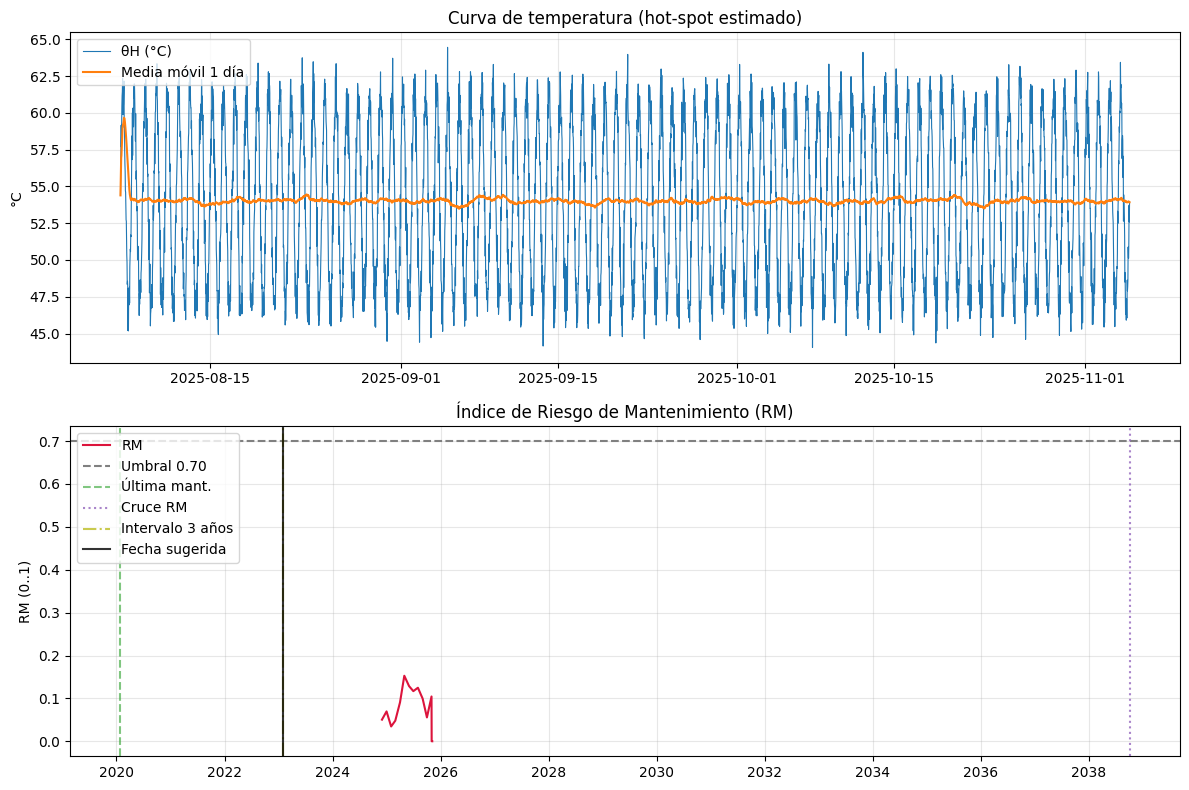

In [6]:

# %% Resumen y gráficas
import pandas as pd, numpy as np, matplotlib.pyplot as plt

row = lab.iloc[-1]
si_func_x, s_func = compute_functional_index(row, WEIGHTS_FUNC, COLS)
si_diel_x, s_diel = compute_dielectric_index(row, WEIGHTS_DIEL, COLS)
HI_x = compute_HI(si_func_x, si_diel_x)

criterio = None
if 'ultima_mant' in globals() and fecha_sugerida is not None:
    fecha_intervalo = pd.to_datetime(ultima_mant) + pd.DateOffset(years=3)
    criterio = 'condición' if (fecha_cruce is not None and (fecha_cruce - pd.Timedelta(days=21)) <= fecha_intervalo) else 'tiempo'

sev_func_df = pd.DataFrame({'Parametro': list(s_func.keys()),
                            'Severidad': [np.nan if pd.isna(v) else float(v) for v in s_func.values()],
                            'Peso': [WEIGHTS_FUNC.get(k, np.nan) for k in s_func.keys()],
                            'Subindice': 'Funcional'})
sev_diel_df = pd.DataFrame({'Parametro': list(s_diel.keys()),
                            'Severidad': [np.nan if pd.isna(v) else float(v) for v in s_diel.values()],
                            'Peso': [WEIGHTS_DIEL.get(k, np.nan) for k in s_diel.keys()],
                            'Subindice': 'Dieléctrico'})
sev_all = pd.concat([sev_func_df, sev_diel_df], ignore_index=True)
sev_all = sev_all.sort_values(['Subindice','Peso','Severidad'], ascending=[True, False, False]).reset_index(drop=True)
print('TABLA DE SEVERIDADES Y PESOS')
print(sev_all)

fig, ax = plt.subplots(2,1, figsize=(12,8))
ax[0].plot(thetaH.index, thetaH.values, color='tab:blue', lw=0.8, label='θH (°C)')
ax[0].plot(thetaH.index, pd.Series(thetaH).rolling('1D').mean(), color='tab:orange', lw=1.5, label='Media móvil 1 día')
ax[0].set_title('Curva de temperatura (hot-spot estimado)')
ax[0].set_ylabel('°C')
ax[0].grid(True, alpha=0.3)
ax[0].legend(loc='upper left')

rm_plot = rm.copy()
if not isinstance(rm_plot.index, pd.DatetimeIndex):
    rm_plot.index = pd.to_datetime(rm_plot.index)
ax[1].plot(rm_plot.index, rm_plot.values, color='crimson', label='RM')
ax[1].axhline(RISK['umbral_RM'], color='gray', ls='--', label=f"Umbral {RISK['umbral_RM']:.2f}")
if 'ultima_mant' in globals():
    ax[1].axvline(pd.to_datetime(ultima_mant), color='tab:green', ls='--', alpha=0.6, label='Última mant.')
if 'fecha_cruce' in globals() and fecha_cruce is not None:
    ax[1].axvline(pd.to_datetime(fecha_cruce), color='tab:purple', ls=':', alpha=0.8, label='Cruce RM')
if 'fecha_intervalo' in globals() and fecha_intervalo is not None:
    ax[1].axvline(pd.to_datetime(fecha_intervalo), color='tab:olive', ls='-.', alpha=0.8, label='Intervalo 3 años')
if 'fecha_sugerida' in globals() and fecha_sugerida is not None:
    ax[1].axvline(pd.to_datetime(fecha_sugerida), color='black', ls='-', alpha=0.8, label='Fecha sugerida')
    ax[1].annotate('Fecha sugerida', xy=(pd.to_datetime(fecha_sugerida), rm_plot.asof(pd.to_datetime(fecha_sugerida))),
                   xytext=(15, 20), textcoords='offset points', arrowprops=dict(arrowstyle='->', color='black'))
ax[1].set_title('Índice de Riesgo de Mantenimiento (RM)')
ax[1].set_ylabel('RM (0..1)')
ax[1].grid(True, alpha=0.3)
ax[1].legend(loc='upper left')
plt.tight_layout(); plt.show()


In [7]:

# %% UI (opcional) para seleccionar última mantención
import ipywidgets as widgets
from IPython.display import display, clear_output

fecha_picker = widgets.DatePicker(description='Última mant.:', disabled=False)
prep_margin = widgets.IntSlider(description='Margen prep (días)', value=21, min=0, max=60)
min_gap = widgets.IntSlider(description='Gap mínimo (días)', value=14, min=0, max=60)
run_btn = widgets.Button(description='Calcular con UI', button_style='primary', icon='calendar')
out = widgets.Output()

display(widgets.VBox([widgets.HBox([fecha_picker, prep_margin, min_gap]), run_btn, out]))

@run_btn.on_click
def _run(b):
    with out:
        clear_output()
        if fecha_picker.value is None:
            print('Selecciona la fecha de la última mantención.')
            return
        ultima = pd.Timestamp(fecha_picker.value)
        fc = project_threshold_crossing_date(rm, RISK['umbral_RM'], start_date=ultima)
        fi = ultima + pd.DateOffset(years=3)
        fs = suggest_maintenance_date(rm, RISK['umbral_RM'], ultima,
                                      prep_margin_days=int(prep_margin.value),
                                      min_gap_dias=int(min_gap.value),
                                      interval_years=3)
        print('Umbral RM:', RISK['umbral_RM'])
        print('Última mant.:', ultima.date())
        print('Cruce estimado RM (post-mant.):', fc)
        print('Fecha por intervalo (3 años):', fi)
        print('Fecha sugerida:', fs)
